<a href="https://colab.research.google.com/github/christeenwagdy758-ops/healthcare_analytics_patient_flow_data./blob/main/Online_Retail_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

print("Path to dataset files:", path)

100%|██████████| 14.5M/14.5M [00:01<00:00, 12.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mashlyn/online-retail-ii-uci/versions/3


In [ ]:
import os

os.listdir(path)

['online_retail_II.csv']

In [ ]:
df = pd.read_csv(path + '/online_retail_II.csv')

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
df.isna().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [ ]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [ ]:
# Filter positive quantities only - negative values are returns
df = df[df['Quantity'] > 0].copy()

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [ ]:
# Add new column for total price = quantity * price per unit
df['totalprice']=df['Quantity']*df['Price']

In [ ]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,totalprice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [ ]:
# Calculate total revenue across all transactions
df['totalprice'].sum()

np.float64(20814291.998000003)

In [ ]:
df['InvoiceDate'].dtype

dtype('O')

In [ ]:
# Calculate total revenue across all transactions
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [ ]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [ ]:
# Extract month from invoice date to analyze monthly trends
df['Month']=df['InvoiceDate'].dt.month
df['Month']

,Month
0,12
1,12
2,12
3,12
4,12
...,...
1067366,12
1067367,12
1067368,12
1067369,12


In [ ]:
# Calculate total revenue per month to identify peak sales periods
monthly_sales=df.groupby('Month')['totalprice'].sum()
monthly_sales

,totalprice
Month,
1,1344073.062
2,1077345.196
3,1551209.491
4,1165743.253
5,1430394.880
6,1514010.040
7,1325902.341
8,1434289.170
9,1982923.183


In [ ]:
# Get the highest monthly revenue value
monthly_sales.max()

2979768.812

In [ ]:
# Get the month with the highest revenue
monthly_sales.idxmax()

np.int32(11)

In [ ]:
# Calculate total revenue per country to identify top markets
country_sales=df.groupby('Country')['totalprice'].sum()
country_sales

,totalprice
Country,
Australia,1.699681e+05
Austria,2.361301e+04
Bahrain,3.109790e+03
Belgium,6.575342e+04
Bermuda,1.253140e+03
Brazil,1.411870e+03
Canada,4.883040e+03
Channel Islands,4.499676e+04
Cyprus,2.498013e+04


In [ ]:
# Get the highest country revenue value
country_sales.max()

17712675.207

In [ ]:
# Get the country with the highest revenue
country_sales.idxmax()

'United Kingdom'

In [ ]:
country_sales.sort_values(ascending=False)

,totalprice
Country,
United Kingdom,1.771268e+07
EIRE,6.644318e+05
Netherlands,5.542323e+05
Germany,4.312625e+05
France,3.569446e+05
Australia,1.699681e+05
Spain,1.091785e+05
Switzerland,1.010113e+05
Sweden,9.190372e+04


In [ ]:
country_sales.head(10)

,totalprice
Country,
Australia,169968.11
Austria,23613.01
Bahrain,3109.79
Belgium,65753.42
Bermuda,1253.14
Brazil,1411.87
Canada,4883.04
Channel Islands,44996.76
Cyprus,24980.13


In [ ]:
top_10=country_sales.sort_values(ascending=False).head(10)
top_10

,totalprice
Country,
United Kingdom,1.771268e+07
EIRE,6.644318e+05
Netherlands,5.542323e+05
Germany,4.312625e+05
France,3.569446e+05
Australia,1.699681e+05
Spain,1.091785e+05
Switzerland,1.010113e+05
Sweden,9.190372e+04


Text(0, 0.5, 'sales')

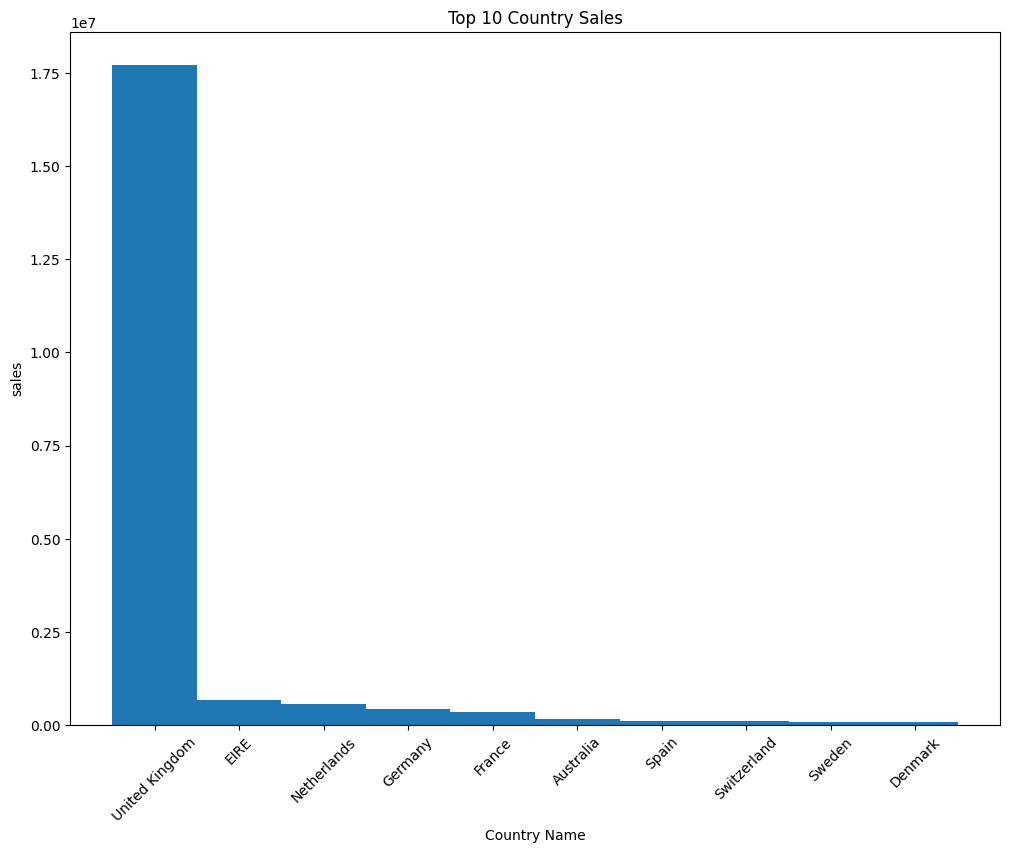

In [ ]:
# Visualize top 10 countries by revenue using a bar chart
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 9))
plt.bar (top_10.index,top_10.values ,width=1)
plt.xticks(rotation=45)
plt.title('Top 10 Country Sales')
plt.xlabel('Country Name')
plt.ylabel('sales')

In [ ]:
num_invoice=df.groupby('Month')['Invoice'].count()
num_invoice

,Invoice
Month,
1,65091
2,55549
3,76392
4,62527
5,70263
6,75106
7,71277
8,67206
9,90509


In [ ]:
df. columns


Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'totalprice', 'Month'],
      dtype='object')

In [ ]:
# Count number of invoices per customer to identify loyal customers
num_invoice_customer=df.groupby('Customer ID')['Invoice'].count()
num_invoice_customer

,Invoice
Customer ID,
12346.0,34
12347.0,253
12348.0,51
12349.0,175
12350.0,17
...,...
18283.0,986
18284.0,28
18285.0,12


In [ ]:
num_invoice_customer.sort_values(ascending=False)

,Invoice
Customer ID,
17841.0,12890
14911.0,11247
12748.0,7230
14606.0,6566
14096.0,5111
...,...
12846.0,1
14845.0,1
16738.0,1


In [ ]:
# Count repeat customers - customers who purchased more than once
num_invoice_customer[num_invoice_customer>1].count()


np.int64(5767)

In [ ]:
# Count one-time customers - customers who purchased only once
num_invoice_customer[num_invoice_customer==1].count()

np.int64(114)

In [ ]:
# Extract day number from invoice date
df['Day']=df['InvoiceDate'].dt.day
df['Day']

,Day
0,1
1,1
2,1
3,1
4,1
...,...
1067366,9
1067367,9
1067368,9
1067369,9


In [ ]:
# Divide month into 3 periods: Early (1-10), Mid (11-20), Late (21-31)
conditions = [
    df['Day'] <= 10,
    df['Day'] <= 20,
    df['Day'] > 20
]

choices = ['Early', 'Mid', 'Late']

df['Period'] = np.select(conditions, choices, default='Late')

In [ ]:
# Calculate total revenue per day to identify peak shopping days
daly_sales=df.groupby('Day')['totalprice'].sum()
daly_sales

,totalprice
Day,
1,680178.091
2,620049.690
3,684645.581
4,699830.580
5,752981.420
6,683697.510
7,1054003.180
8,882053.591
9,895344.280


In [ ]:
# Calculate total revenue per Period to identify peak shopping days
daly_sales=df.groupby('Period')['totalprice'].sum()
daly_sales

,totalprice
Period,
Early,7665056.153
Late,6281805.618
Mid,6867430.227


In [ ]:
daly_sales.idxmax()



'Early'

In [ ]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'totalprice', 'Month', 'Day',
       'Period'],
      dtype='object')

In [ ]:
num_StockCode=df.groupby('StockCode')['Invoice'].count()
num_StockCode.sort_values(ascending=False).head(10)

,Invoice
StockCode,
85123A,5692
85099B,4129
22423,4065
21212,3290
20725,3179
84879,2939
47566,2743
21232,2557
22383,2508


In [ ]:
#Find top 10 most sold products by number of invoices
Description=df.groupby('Description')['Invoice'].count()
Description.sort_values(ascending=False).head(10)

,Invoice
Description,
WHITE HANGING HEART T-LIGHT HOLDER,5783
REGENCY CAKESTAND 3 TIER,4065
JUMBO BAG RED RETROSPOT,3395
ASSORTED COLOUR BIRD ORNAMENT,2939
PARTY BUNTING,2742
LUNCH BAG BLACK SKULL.,2484
STRAWBERRY CERAMIC TRINKET BOX,2429
JUMBO STORAGE BAG SUKI,2400
HEART OF WICKER SMALL,2299


In [ ]:
df.to_csv('retail_cleaned.csv', index=False)

In [ ]:
from google.colab import files
files.download('retail_cleaned.csv')

FileNotFoundError: Cannot find file: retail_cleaned.csv